# Data Validation

## Explore the data

In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
df = pd.read_csv(r"D:\Iyyappa\Analytics Projects\loan_data.csv")

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## Missing Value

In [6]:
# Count missing values per column
missing_counts = df.isnull().sum()

print("Missing values per column:\n", missing_counts)


Missing values per column:
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


## Duplicate

In [7]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


## Data Type

In [8]:
numeric_cols = [
    "person_age", "person_income", "person_emp_exp",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length", "credit_score", "loan_status"
]

categorical_cols = [
    "person_gender", "person_education",
    "person_home_ownership", "loan_intent",
    "previous_loan_defaults_on_file"
]

# Confirm numeric columns
for col in numeric_cols:
    assert pd.api.types.is_numeric_dtype(df[col]), f"{col} is not numeric"

# Confirm categorical columns
for col in categorical_cols:
    assert df[col].dtype == "object", f"{col} is not categorical"

print("Data types validated successfully.")

Data types validated successfully.


## Range & Logical Validation

In [9]:
# Age validation
df.loc[(df["person_age"] < 18) | (df["person_age"] > 100), "person_age"].describe()

count      7.000000
mean     129.000000
std       14.809907
min      109.000000
25%      119.500000
50%      123.000000
75%      144.000000
max      144.000000
Name: person_age, dtype: float64

Remove older than 100 years old.

In [10]:
# Remove rows where age is greater than 100 (in place)
df.drop(df[df["person_age"] > 100].index, inplace=True)

In [11]:
# Confirm rows were removed
print("Remaining rows:", df.shape[0])

# Confirm no ages > 100 remain
assert (df["person_age"] <= 100).all(), "Ages over 100 still exist!"
print("✅ In-place deletion successful")

Remaining rows: 44993
✅ In-place deletion successful


In [12]:
# Income, loan amount, interest rate
df.loc[df["person_income"] < 0, "person_income"].count()
df.loc[df["loan_amnt"] <= 0, "loan_amnt"].count()
df.loc[(df["loan_int_rate"] < 0) | (df["loan_int_rate"] > 100), "loan_int_rate"].count()

np.int64(0)

In [13]:
# Credit score range check (typical FICO scale)
df.loc[(df["credit_score"] < 300) | (df["credit_score"] > 850), "credit_score"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: credit_score, dtype: float64

## Categorical Value Validation

In [14]:
# Inspect unique values
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].unique())


person_gender unique values:
['female' 'male']

person_education unique values:
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

person_home_ownership unique values:
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

loan_intent unique values:
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

previous_loan_defaults_on_file unique values:
['No' 'Yes']


## Cross‑Field Logical Consistency Checks

In [15]:
# Employment experience should not exceed age - 18
invalid_exp = df[df["person_emp_exp"] > (df["person_age"] - 18)]

print("Invalid employment experience rows:", invalid_exp.shape[0])

Invalid employment experience rows: 0


In [16]:
# Loan percent income consistency
calculated_ratio = df["loan_amnt"] / df["person_income"]
difference = np.abs(calculated_ratio - df["loan_percent_income"])

print("Rows with inconsistent loan percent income:",
      (difference > 0.05).sum())

Rows with inconsistent loan percent income: 0


## Target Variable Validation

In [17]:
# Check values
print(df["loan_status"].value_counts())

# Assert binary classification
assert set(df["loan_status"].unique()).issubset({0, 1})

loan_status
0    34993
1    10000
Name: count, dtype: int64


# EDA

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Univariate Analysis – Numerical Features

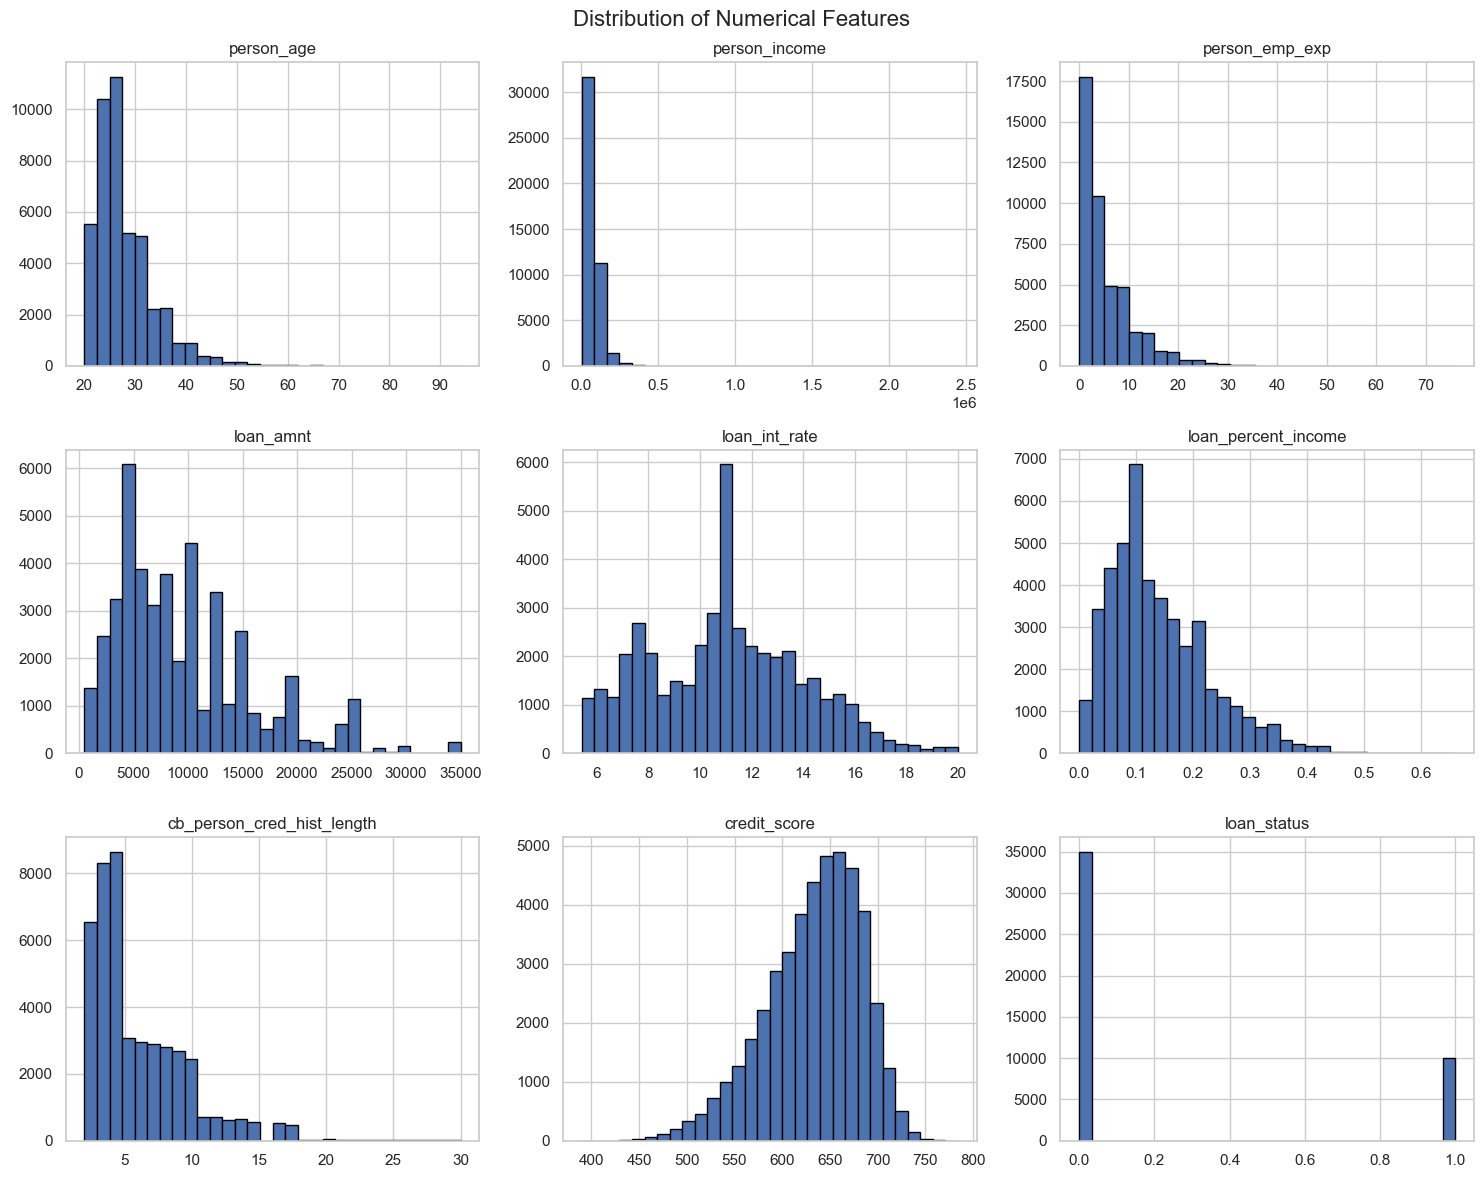

In [19]:
df[numeric_cols].hist(
    bins=30,
    figsize=(15, 12),
    edgecolor="black"
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


## Univariate Analysis – Categorical Features

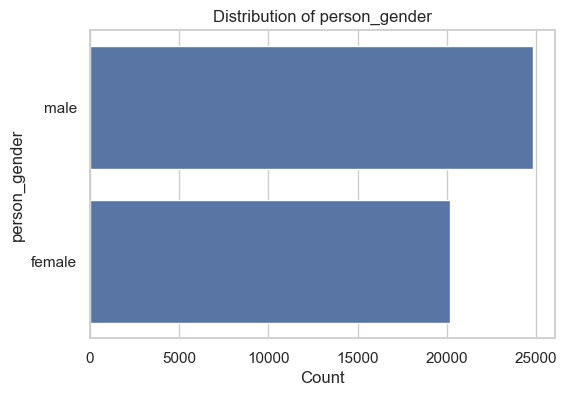

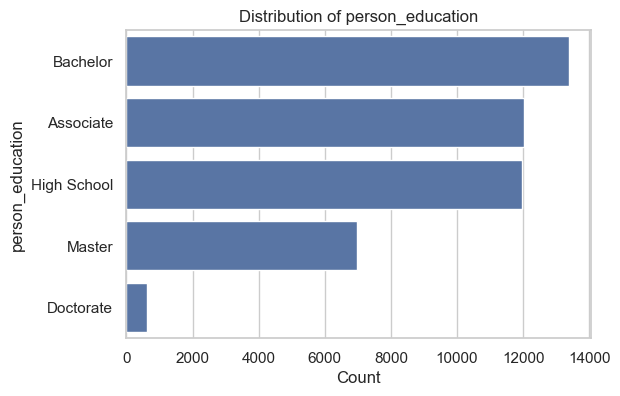

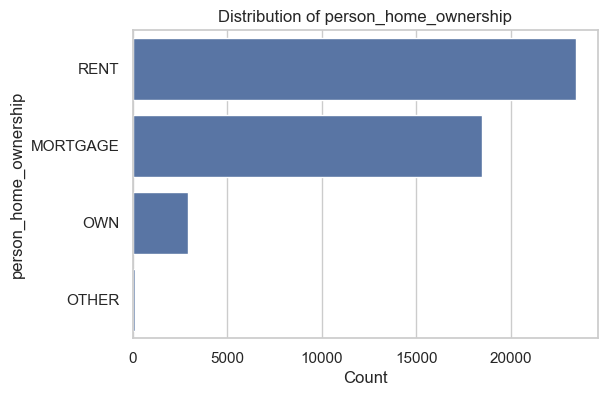

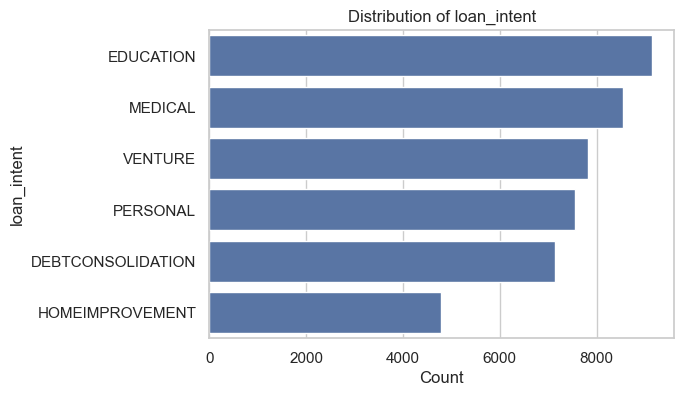

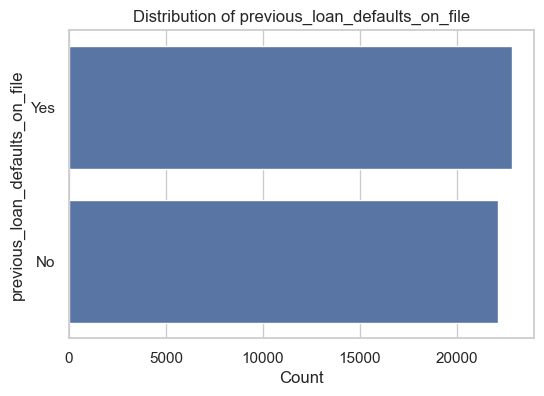

In [20]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

## Target Variable Analysis

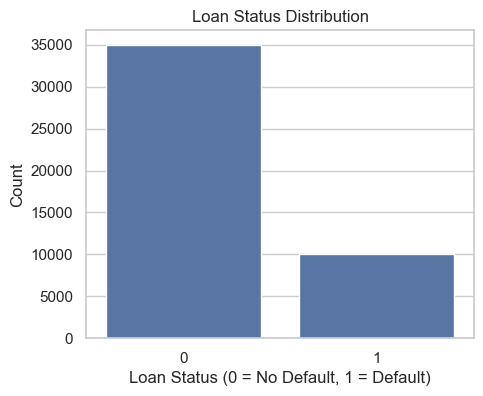

In [21]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.show()

## Bivariate Analysis – Numerical vs Target

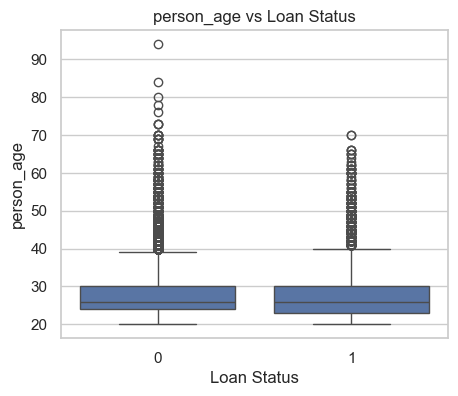

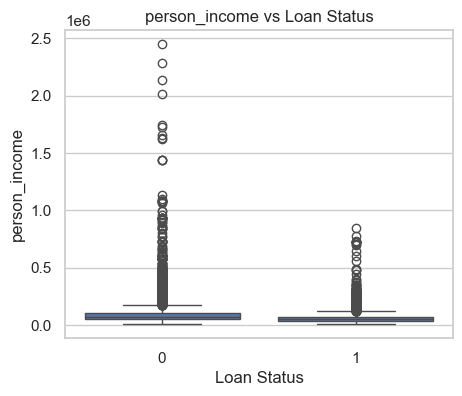

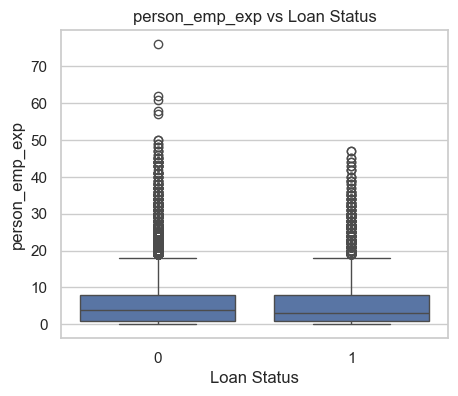

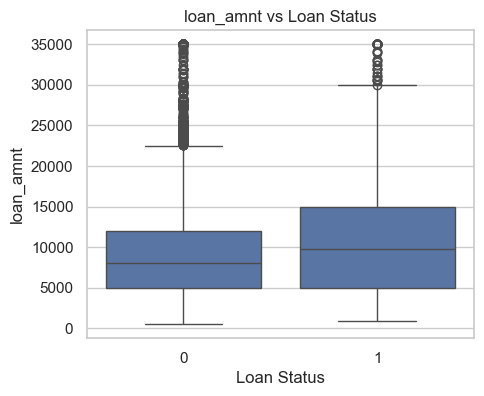

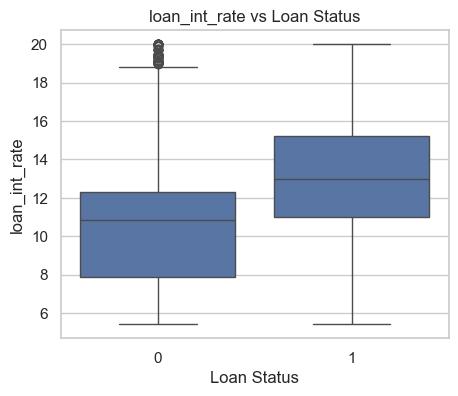

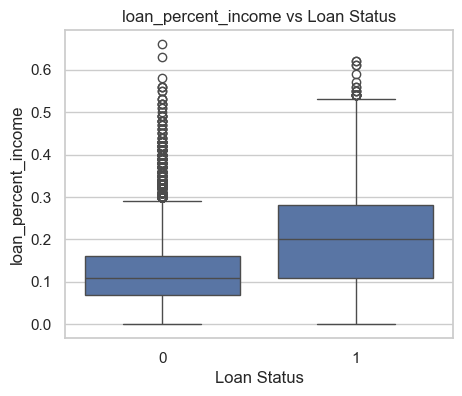

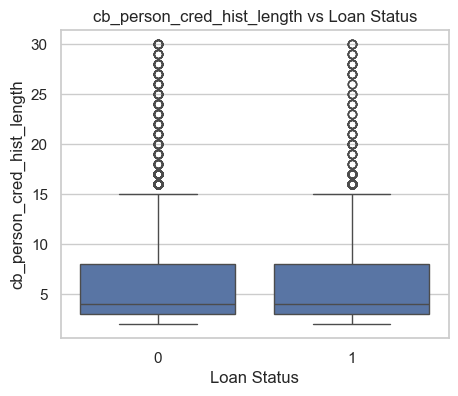

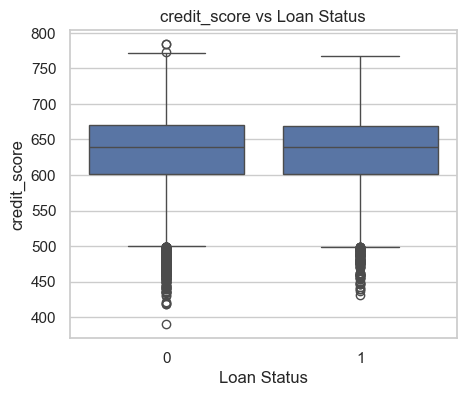

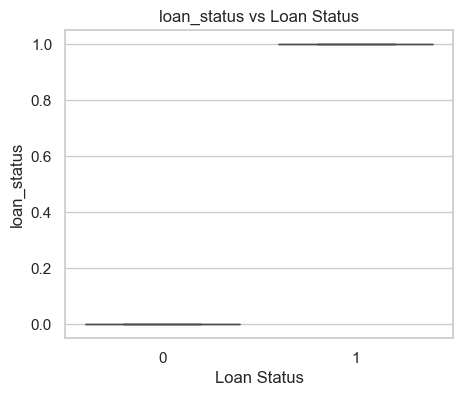

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(
        data=df,
        x="loan_status",
        y=col
    )
    plt.title(f"{col} vs Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel(col)
    plt.show()

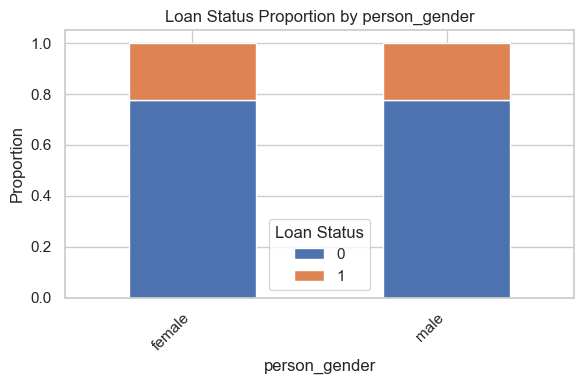

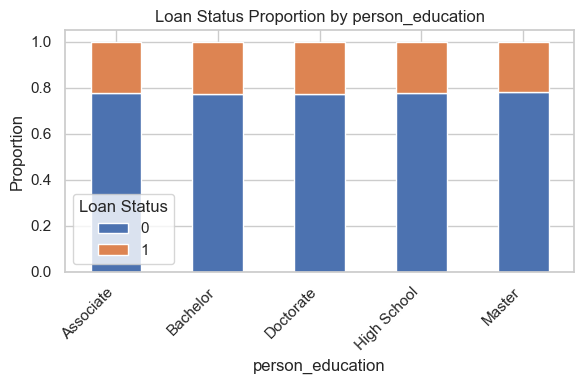

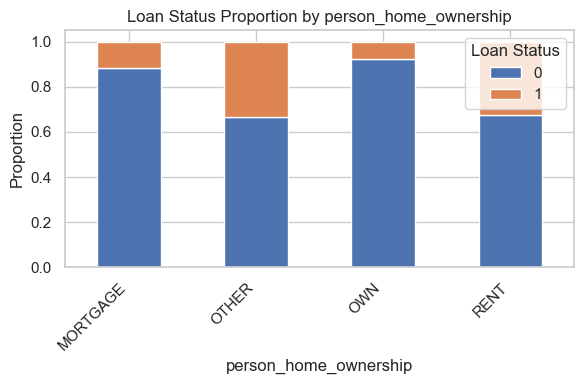

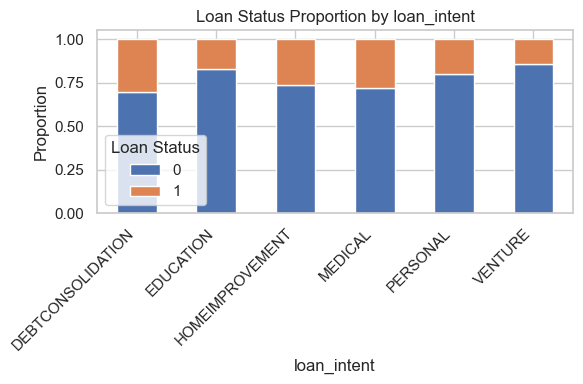

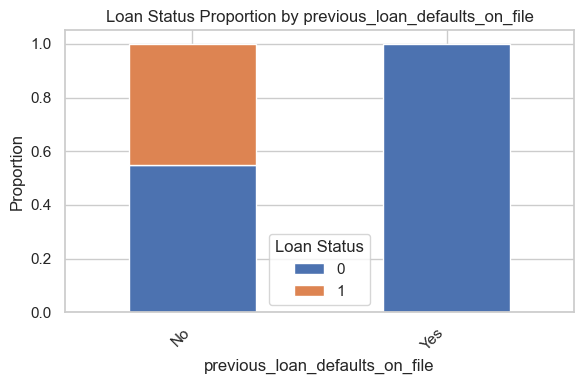

In [23]:
for col in categorical_cols:
    prop_df = (
        pd.crosstab(df[col], df["loan_status"], normalize="index")
    )

    prop_df.plot(
        kind="bar",
        stacked=True,
        figsize=(6,4)
    )
    plt.title(f"Loan Status Proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="Loan Status")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Correlation

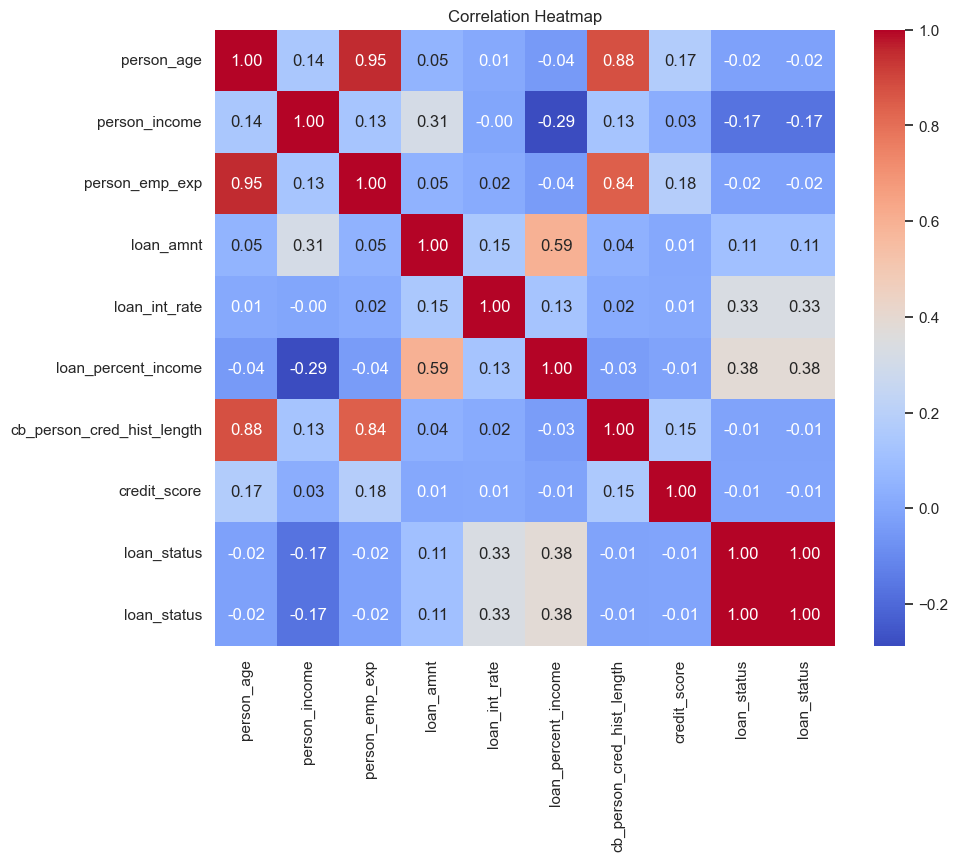

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols + ["loan_status"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

## Key Business Relationships

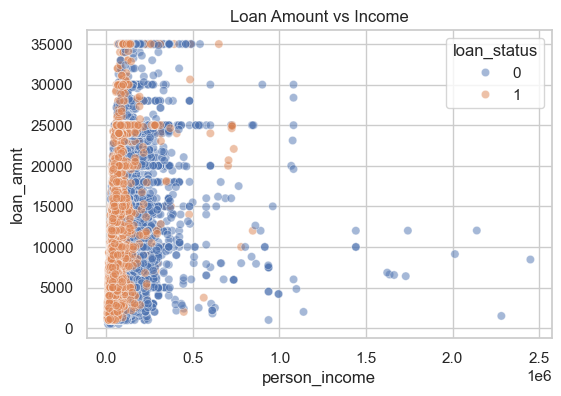

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="person_income",
    y="loan_amnt",
    hue="loan_status",
    alpha=0.5
)
plt.title("Loan Amount vs Income")
plt.show()

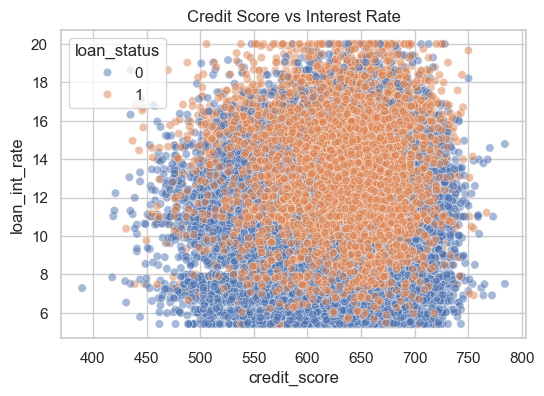

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="credit_score",
    y="loan_int_rate",
    hue="loan_status",
    alpha=0.5
)
plt.title("Credit Score vs Interest Rate")
plt.show()

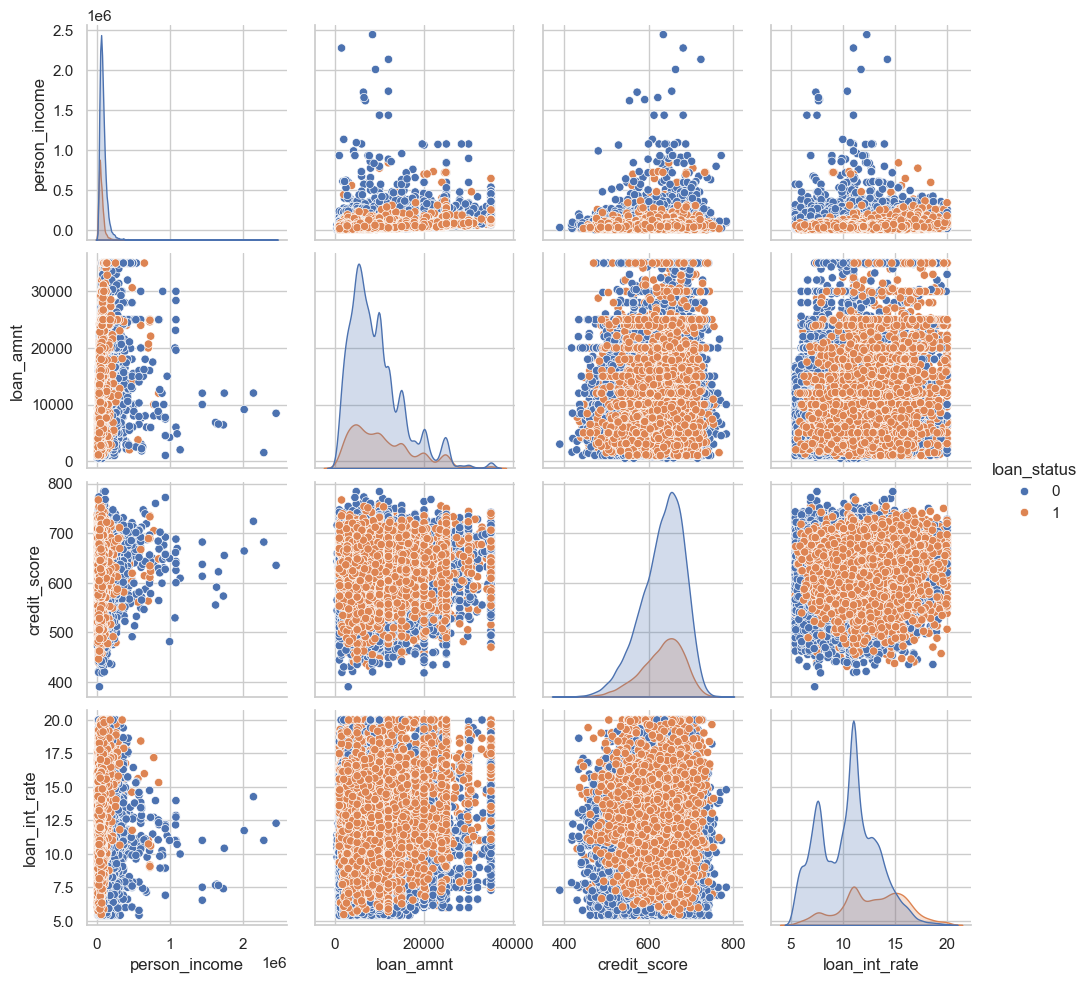

In [27]:
key_features = [
    "person_income",
    "loan_amnt",
    "credit_score",
    "loan_int_rate",
    "loan_status"
]

sns.pairplot(
    df[key_features],
    hue="loan_status",
    diag_kind="kde"
)
plt.show()


# Feature Engineering

In [28]:
df_fe = df.copy()

## Transform Skewed Numerical Features

In [29]:
df_fe["log_person_income"] = np.log1p(df_fe["person_income"])
df_fe["log_loan_amnt"] = np.log1p(df_fe["loan_amnt"])
df_fe["log_loan_percent_income"] = np.log1p(df_fe["loan_percent_income"])

## Ratio‑Based Financial Features

In [30]:
df_fe["loan_to_income_ratio"] = (
    df_fe["loan_amnt"] / df_fe["person_income"]
)

In [31]:
df_fe["employment_stability"] = (
    df_fe["person_emp_exp"] / df_fe["person_age"]
)

## Credit History Strength Features

In [32]:
df_fe["credit_hist_age_ratio"] = (
    df_fe["cb_person_cred_hist_length"] / df_fe["person_age"]
)

In [33]:
df_fe["credit_score_band"] = pd.cut(
    df_fe["credit_score"],
    bins=[300, 580, 670, 740, 800, 850],
    labels=["Poor", "Fair", "Good", "Very_Good", "Excellent"],
    right=True
)

## Age & Experience Bucketing

In [34]:
df_fe["age_group"] = pd.cut(
    df_fe["person_age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"],
    right=True
)

In [35]:
df_fe["experience_level"] = pd.cut(
    df_fe["person_emp_exp"],
    bins=[-1, 1, 5, 10, 20, 60],
    labels=["Entry", "Junior", "Mid", "Senior", "Expert"]
)

##  Binary Risk Flags

In [36]:
df_fe["high_interest_rate"] = (df_fe["loan_int_rate"] > 15).astype(int)

In [37]:
df_fe["high_loan_burden"] = (
    df_fe["loan_percent_income"] > 0.4
).astype(int)

In [38]:
df_fe["previous_default"] = (
    df_fe["previous_loan_defaults_on_file"] == "Yes"
).astype(int)

## Encoding Categorical Variables

In [39]:
categorical_nominal = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

df_fe = pd.get_dummies(
    df_fe,
    columns=categorical_nominal,
    drop_first=True
)

## Feature Pruning

In [40]:
drop_cols = [
    "previous_loan_defaults_on_file"  # replaced by previous_default
]

df_fe.drop(columns=drop_cols, inplace=True)

## Final Sanity Check

In [41]:
df_fe.info()


<class 'pandas.core.frame.DataFrame'>
Index: 44993 entries, 0 to 44999
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   person_age                    44993 non-null  float64 
 1   person_income                 44993 non-null  float64 
 2   person_emp_exp                44993 non-null  int64   
 3   loan_amnt                     44993 non-null  float64 
 4   loan_int_rate                 44993 non-null  float64 
 5   loan_percent_income           44993 non-null  float64 
 6   cb_person_cred_hist_length    44993 non-null  float64 
 7   credit_score                  44993 non-null  int64   
 8   loan_status                   44993 non-null  int64   
 9   log_person_income             44993 non-null  float64 
 10  log_loan_amnt                 44993 non-null  float64 
 11  log_loan_percent_income       44993 non-null  float64 
 12  loan_to_income_ratio          44993 non-null  float

In [42]:
df_fe.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,log_person_income,...,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,11.183713,...,False,True,False,False,True,False,False,False,True,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,9.415971,...,True,False,False,True,False,True,False,False,False,False
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,9.428592,...,True,False,False,False,False,False,False,True,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,11.286702,...,False,False,False,False,True,False,False,True,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,11.099469,...,False,True,False,False,True,False,False,True,False,False


# BASELINE MODEL: LOGISTIC REGRESSION

In [43]:
categorical_cols = df_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Remaining categorical columns:", categorical_cols)

Remaining categorical columns: ['credit_score_band', 'age_group', 'experience_level']


In [44]:
if len(categorical_cols) > 0:
    df_fe = pd.get_dummies(
        df_fe,
        columns=categorical_cols,
        drop_first=True
    )

In [45]:
df_fe.dtypes.value_counts()

bool       26
float64    12
int64       6
Name: count, dtype: int64

In [46]:
assert df_fe.select_dtypes(include=["object", "category"]).empty, \
       "Non-numeric columns still exist!"

In [47]:
df.dtypes.value_counts()

float64    6
object     5
int64      3
Name: count, dtype: int64

In [48]:
X = df_fe.drop(columns=["loan_status"])
y = df_fe["loan_status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [49]:
from sklearn.preprocessing import StandardScaler

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [50]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [51]:
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Evaluate

In [52]:
# Class predictions
y_pred = log_reg.predict(X_test)

# Probabilities (needed for AUC, ROC, threshold tuning)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")


Accuracy : 0.8635
Precision: 0.6339
Recall   : 0.9135
F1 Score : 0.7485
ROC AUC  : 0.9579


In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9717    0.8493    0.9064      6999
           1     0.6339    0.9135    0.7485      2000

    accuracy                         0.8635      8999
   macro avg     0.8028    0.8814    0.8274      8999
weighted avg     0.8966    0.8635    0.8713      8999



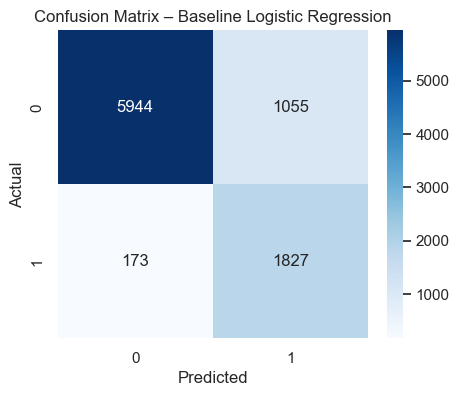

In [55]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Baseline Logistic Regression")
plt.show()


## ROC

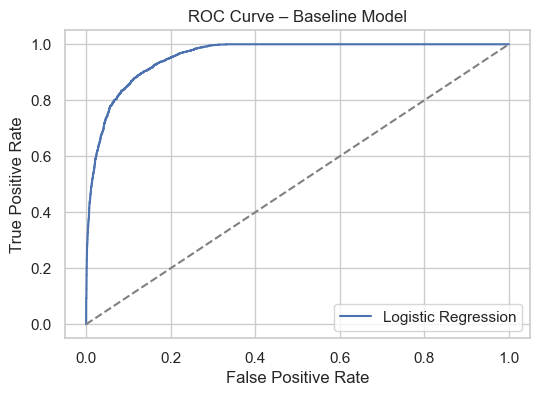

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Baseline Model")
plt.legend()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


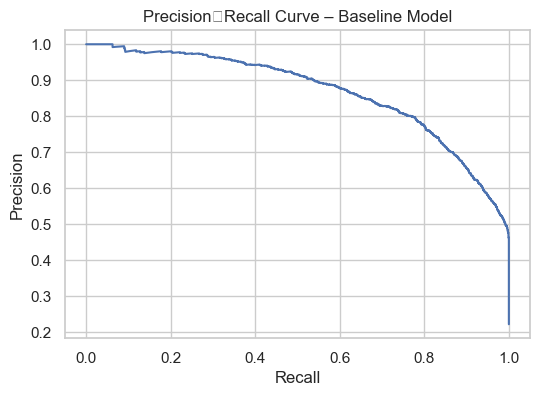

In [57]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision‑Recall Curve – Baseline Model")
plt.show()

# CREDIT SCORECARD

In [58]:
pd_pred = log_reg.predict_proba(X_test)[:, 1]

In [59]:
log_odds = np.log((1 - pd_pred) / pd_pred)

In [60]:
PDO = 50
base_score = 600
base_odds = 50

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

In [61]:
credit_score = offset + factor * log_odds

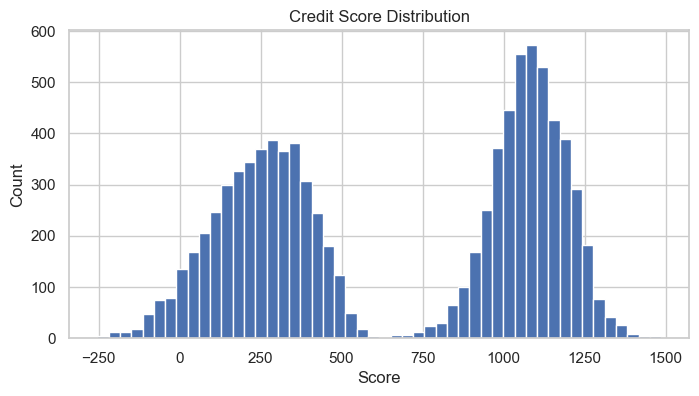

In [62]:
plt.figure(figsize=(8,4))
plt.hist(credit_score, bins=50)
plt.title("Credit Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

In [63]:
score_df = pd.DataFrame({
    "score": credit_score,
    "loan_status": y_test.values
})

score_df["score_band"] = pd.qcut(
    score_df["score"],
    10,
    duplicates="drop"
)

default_rate = (
    score_df.groupby("score_band")["loan_status"]
    .mean()
)

default_rate

C:\Users\Dell\AppData\Local\Temp\ipykernel_18592\3133136639.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_df.groupby("score_band")["loan_status"]


score_band
(-253.308, 115.659]     0.940000
(115.659, 214.81]       0.695556
(214.81, 299.709]       0.353333
(299.709, 387.173]      0.173333
(387.173, 833.205]      0.060000
(833.205, 994.544]      0.000000
(994.544, 1059.68]      0.000000
(1059.68, 1114.054]     0.000000
(1114.054, 1183.446]    0.000000
(1183.446, 1485.781]    0.000000
Name: loan_status, dtype: float64

In [64]:
score_df["risk_band"] = pd.cut(
    score_df["score"],
    bins=[300, 500, 600, 700, 850],
    labels=["High Risk", "Medium Risk", "Low Risk", "Very Low Risk"]
)

score_df.groupby("risk_band")["loan_status"].mean()

C:\Users\Dell\AppData\Local\Temp\ipykernel_18592\2296192086.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_df.groupby("risk_band")["loan_status"].mean()


risk_band
High Risk        0.129919
Medium Risk      0.019608
Low Risk         0.000000
Very Low Risk    0.000000
Name: loan_status, dtype: float64

In [65]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": log_reg.coef_[0]
})

coef_df["points"] = -coef_df["coef"] * factor
coef_df.sort_values("points", ascending=False)

,feature,coef,points
16,previous_default,-5.319022,383.686339
10,log_loan_percent_income,-3.855948,278.147843
23,person_home_ownership_OWN,-1.793027,129.339564
29,loan_intent_VENTURE,-1.335113,96.308047
38,age_group_65+,-1.168512,84.290296
25,loan_intent_EDUCATION,-0.841484,60.700224
8,log_person_income,-0.750052,54.104793
28,loan_intent_PERSONAL,-0.650351,46.912891
9,log_loan_amnt,-0.492114,35.498529
7,credit_score,-0.413475,29.825943


Thank you for coming.